# Linear regression and baselines

Two course colabs combined: the linear regression walkthrough on California housing, and the one that
builds baseline models to compare it against.

1. Train/test split and a `Pipeline` with scaling + `LinearRegression`
2. Evaluation: `score`, `cross_val_score`, `cross_validate`
3. Diagnosing under/overfitting with learning curves
4. Looking at the learned weights
5. Is the model actually any good? Comparing with `DummyRegressor` and `permutation_test_score`
6. Final evaluation on the test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import (train_test_split, ShuffleSplit, cross_val_score,
                                     cross_validate, cross_val_predict, learning_curve,
                                     permutation_test_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(306)

## Data and cross validation setup

`ShuffleSplit` with 10 splits: each split randomly puts 20% of the training data aside for validation.
Unlike `KFold`, the validation sets can overlap between splits.

In [2]:
features, labels = fetch_california_housing(as_frame=True, return_X_y=True)
print("features:", features.shape, " labels:", labels.shape)

cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

features: (20640, 8)  labels: (20640,)


The test set is put aside now and not touched until the very end. Everything else (cross validation,
model choices) happens on the training part only.

In [3]:
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, random_state=42)

print("train:", train_features.shape[0], " test:", test_features.shape[0])
assert train_features.shape[0] == train_labels.shape[0]
assert test_features.shape[0] == test_labels.shape[0]

train: 15480  test: 5160


## The model

Scaling isn't needed for `LinearRegression` to find the best fit (the normal equation gives the same
predictions either way), but it makes the coefficients comparable with each other, which helps later.

In [4]:
lin_reg = Pipeline([("feature_scaling", StandardScaler()),
                    ("lin_reg", LinearRegression())])
lin_reg.fit(train_features, train_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_scaling', ...), ('lin_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [5]:
print("intercept (w0):", lin_reg[-1].intercept_)
pd.Series(lin_reg[-1].coef_, index=features.columns).round(3)

intercept (w0): 2.0703489205426377


MedInc        0.852
HouseAge      0.121
AveRooms     -0.302
AveBedrms     0.349
Population   -0.002
AveOccup     -0.041
Latitude     -0.893
Longitude    -0.868
dtype: float64

`lin_reg[-1]` is the last step of the pipeline. Since the features are standardised, the intercept is
just the mean of the training labels (about 2.07, i.e. $207k), and each coefficient is the change in
prediction for a one standard deviation change in that feature.

## Evaluation

### score

For regressors `score` returns R2: 1 is perfect, 0 is no better than predicting the mean.

In [6]:
print(f"train R2: {lin_reg.score(train_features, train_labels):.3f}")
print(f"test R2:  {lin_reg.score(test_features, test_labels):.3f}")

train R2: 0.610
test R2:  0.591


Train and test scores are close, so it's not overfitting, but around 0.6 isn't great either. That
pattern (similar and mediocre) points to **underfitting**: a straight line is too simple for this data.

### cross_val_score

One train/test split could be lucky or unlucky. Cross validation gives a score on each of the 10 splits.
sklearn scorers always follow "higher is better", so error metrics come back negated
(`neg_mean_squared_error`).

In [7]:
scores = cross_val_score(lin_reg, train_features, train_labels,
                         scoring='neg_mean_squared_error', cv=cv)
mse = -scores
print(mse.round(3))
print(f"MSE: {mse.mean():.3f} +/- {mse.std():.3f}")

[0.5   0.522 0.559 0.521 0.561 0.505 0.524 0.548 0.501 0.547]
MSE: 0.529 +/- 0.022


Other options for `scoring` in regression: `r2`, `neg_mean_absolute_error`, `neg_root_mean_squared_error`,
`neg_median_absolute_error`, `neg_mean_absolute_percentage_error`, `explained_variance`, `max_error`.

In [8]:
for metric in ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error',
               'neg_mean_absolute_percentage_error']:
    s = cross_val_score(lin_reg, train_features, train_labels, scoring=metric, cv=cv)
    print(f"{metric:38s} {s.mean():8.3f} +/- {s.std():.3f}")

r2                                        0.601 +/- 0.019


neg_mean_absolute_error                  -0.532 +/- 0.010


neg_root_mean_squared_error              -0.727 +/- 0.015


neg_mean_absolute_percentage_error       -0.316 +/- 0.004


### cross_validate

Same as `cross_val_score` but returns more: fit/score times, train scores (with `return_train_score`),
and the fitted model from each split (with `return_estimator`).

In [9]:
cv_results = cross_validate(lin_reg, train_features, train_labels, cv=cv,
                            scoring="neg_mean_squared_error",
                            return_train_score=True, return_estimator=True)
cv_results.keys()

dict_keys(['fit_time', 'score_time', 'estimator', 'test_score', 'train_score'])

In [10]:
train_error = -cv_results['train_score']
test_error = -cv_results['test_score']
print(f"train MSE: {train_error.mean():.3f} +/- {train_error.std():.3f}")
print(f"valid MSE: {test_error.mean():.3f} +/- {test_error.std():.3f}")

train MSE: 0.519 +/- 0.006
valid MSE: 0.529 +/- 0.022


Same conclusion as before: both errors are similar and fairly high. Validation error varies more between
splits than training error, which is normal since each validation set is smaller.

## Learning curves

`learning_curve` retrains the model on increasing amounts of training data and records train and
validation error at each size. The shape tells you what's wrong:

* **underfitting**: both curves flatten out close together at a high error. More data won't help, the
  model needs more capacity.
* **overfitting**: a big gap between low training error and higher validation error. More data or
  regularisation helps.

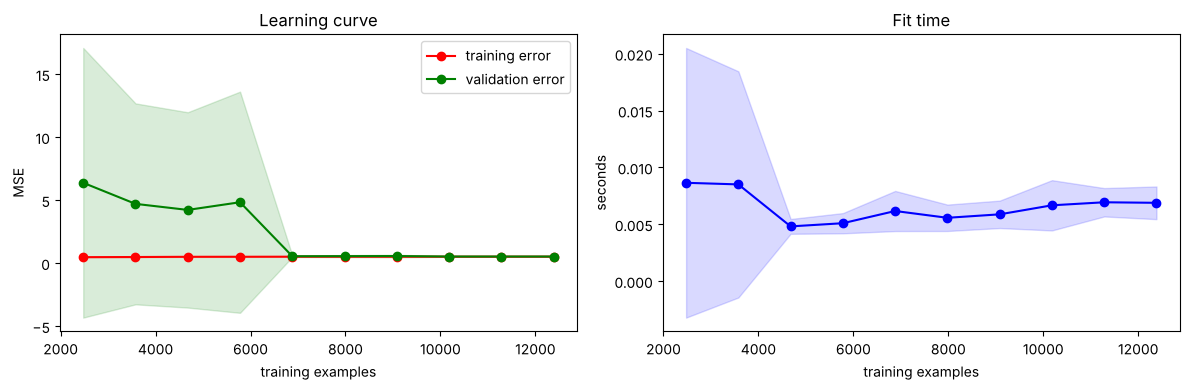

In [11]:
train_sizes, train_scores, valid_scores, fit_times, _ = learning_curve(
    lin_reg, train_features, train_labels, cv=cv, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.2, 1.0, 10), return_times=True, n_jobs=-1)

def plot_band(x, scores, label, colour):
    m, s = scores.mean(axis=1), scores.std(axis=1)
    plt.fill_between(x, m - s, m + s, alpha=0.15, color=colour)
    plt.plot(x, m, 'o-', color=colour, label=label)

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_band(train_sizes, -train_scores, 'training error', 'r')
plot_band(train_sizes, -valid_scores, 'validation error', 'g')
plt.xlabel('training examples'); plt.ylabel('MSE'); plt.legend(); plt.title('Learning curve')

plt.subplot(1, 2, 2)
plot_band(train_sizes, fit_times, 'fit time', 'b')
plt.xlabel('training examples'); plt.ylabel('seconds'); plt.title('Fit time')
plt.tight_layout()
plt.show()

Both curves level off around 0.52-0.53 and sit close together: the textbook underfitting shape. With
very little data the model fits the training set well and generalises badly, but after a few thousand
samples nothing changes. Fit time grows with data size, but it's milliseconds for a linear model.

(The course version of the plotting function read `fit_times` from a global variable, it's passed in
explicitly here.)

## Looking at the weights

`cross_validate` gave back 10 fitted models. If the coefficients jump around a lot between them, the model
is unstable. Here they barely move:

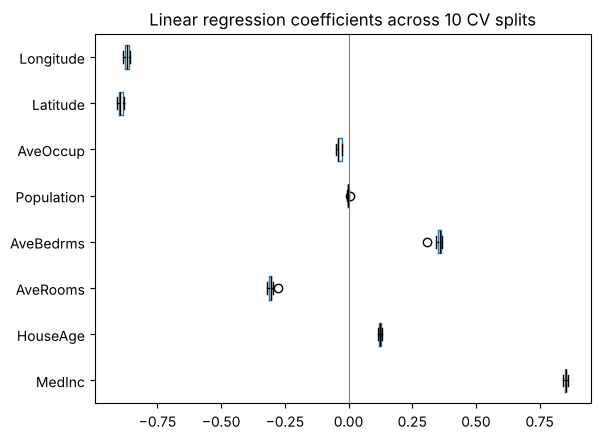

In [12]:
coefs = pd.DataFrame([est[-1].coef_ for est in cv_results['estimator']], columns=features.columns)

coefs.plot.box(vert=False, color={"whiskers": "black", "medians": "black", "caps": "black"})
plt.axvline(0, c='grey', lw=0.8)
plt.title("Linear regression coefficients across 10 CV splits")
plt.show()

In [13]:
coefs.describe().loc[['mean', 'std']].round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,0.852,0.123,-0.304,0.354,-0.002,-0.037,-0.894,-0.870
std,0.006,0.004,0.011,0.018,0.003,0.009,0.010,0.009


MedInc has the largest positive weight. Latitude and Longitude have large negative weights: further north
or further east (inland) means cheaper, holding everything else fixed. AveRooms is negative while
AveBedrms is positive, which looks odd until you remember they're highly correlated (0.85), so the model
can trade one off against the other.

## Predicted vs actual

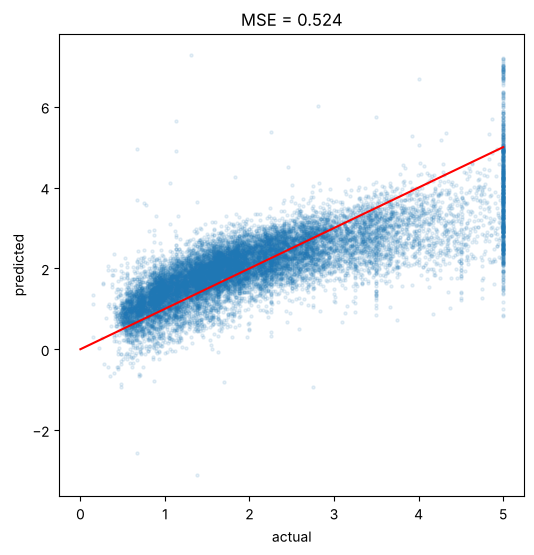

In [14]:
cv_pred = cross_val_predict(lin_reg, train_features, train_labels)

plt.figure(figsize=(6, 6))
plt.scatter(train_labels, cv_pred, alpha=0.1, s=5)
plt.plot([0, 5], [0, 5], 'r-')
plt.xlabel('actual'); plt.ylabel('predicted')
plt.title(f"MSE = {mean_squared_error(train_labels, cv_pred):.3f}")
plt.show()

In [15]:
(cv_pred < 0).sum(), cv_pred.min().round(2)

(np.int64(62), np.float64(-3.11))

* The vertical line of points at actual = 5 is the capped target: the true value could be anything above
  $500k, and the predictions for those blocks are all over the place.
* A handful of predictions are negative, which is impossible for a house price. Nothing in plain linear
  regression stops that. (The course notes suggested forcing the weights to be positive, but that wouldn't
  fix it, since the features themselves can be negative after scaling. Predicting `log(price)` or clipping
  predictions at 0 are the usual fixes.)
* There's also a visible curve: low values get over-predicted and high values under-predicted, another
  sign the relationship isn't linear.

---

## Baselines

R2 of 0.6 and MSE of 0.53: is that good? It helps to compare against models that don't learn anything.

### DummyRegressor

Ignores the features and always predicts one value:

* `mean` / `median` of the training labels
* `quantile` - a given quantile of the training labels
* `constant` - a fixed number you choose

MAE is used from here on because it's in the same units as the target ($100k).

In [16]:
def cv_mae(model):
    res = cross_validate(model, train_features, train_labels, cv=cv,
                         scoring="neg_mean_absolute_error", n_jobs=-1)
    return -res["test_score"]

errors = pd.DataFrame({
    'linear regression': cv_mae(lin_reg),
    'dummy mean': cv_mae(DummyRegressor(strategy='mean')),
    'dummy median': cv_mae(DummyRegressor(strategy='median')),
    'dummy quantile 0.55': cv_mae(DummyRegressor(strategy='quantile', quantile=0.55)),
    'dummy constant 2': cv_mae(DummyRegressor(strategy='constant', constant=2)),
})
errors.agg(['mean', 'std']).T.round(3)

,mean,std
linear regression,0.532,0.010
dummy mean,0.910,0.010
dummy median,0.881,0.009
dummy quantile 0.55,0.887,0.009
dummy constant 2,0.897,0.009


The median baseline does best among the dummies, which makes sense: for MAE, the median is the single
value that minimises error. Linear regression is about 0.53 vs 0.88, so it's clearly learning something.

### permutation_test_score

A different kind of baseline. It shuffles the target so the link between features and labels is
destroyed, retrains the model on that, and repeats. The scores on shuffled data show how well the model
does "by chance". It also returns a p-value for the null hypothesis that features and target are
independent.

In [17]:
score, permutation_scores, pvalue = permutation_test_score(
    lin_reg, train_features, train_labels, cv=cv, scoring="neg_mean_absolute_error",
    n_permutations=30, n_jobs=-1, random_state=0)

print(f"real data MAE:          {-score:.3f}")
print(f"shuffled data MAE:      {-permutation_scores.mean():.3f} +/- {permutation_scores.std():.3f}")
print(f"p-value:                {pvalue:.3f}")

real data MAE:          0.532
shuffled data MAE:      0.913 +/- 0.004
p-value:                0.032


The p-value is (1 + number of permutations scoring at least as well) / (n_permutations + 1), so with 30
permutations 1/31 = 0.032 is the smallest it can be. None of the shuffled runs came close.

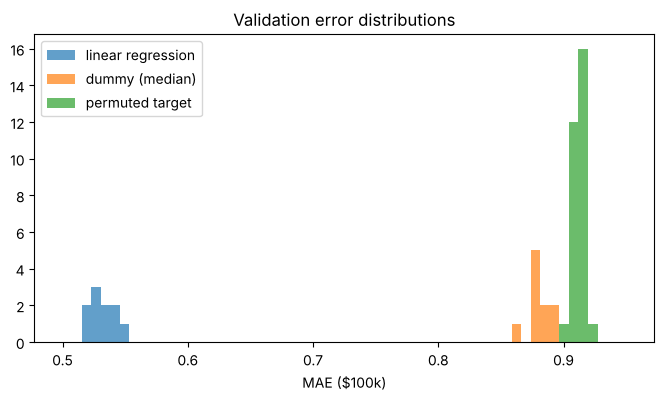

In [18]:
compare = pd.DataFrame({'linear regression': errors['linear regression'],
                        'dummy median': errors['dummy median']})
plt.figure(figsize=(8, 4))
bins = np.linspace(0.5, 0.95, 60)
plt.hist(compare['linear regression'], bins=bins, alpha=0.7, label='linear regression')
plt.hist(compare['dummy median'], bins=bins, alpha=0.7, label='dummy (median)')
plt.hist(-permutation_scores, bins=bins, alpha=0.7, label='permuted target')
plt.xlabel('MAE ($100k)'); plt.legend()
plt.title('Validation error distributions')
plt.show()

Both baselines sit around 0.88-0.92 and the real model is far to the left. Still a lot of room for
improvement though (later notebooks get this down to around 0.3 with tree ensembles).

## Final evaluation on the test set

The course colab picked the CV split model with the lowest validation error and used that as the "best"
model. That's not really choosing anything: all 10 models are the same model on slightly different
data, and the lowest error is mostly luck in which rows ended up in that validation set. The normal thing
to do is retrain on the full training set (which `lin_reg` already is) and evaluate once.

In [19]:
test_pred = lin_reg.predict(test_features)
print(f"test MAE: {mean_absolute_error(test_labels, test_pred):.3f}")
print(f"test MSE: {mean_squared_error(test_labels, test_pred):.3f}")
print(f"test R2:  {lin_reg.score(test_features, test_labels):.3f}")

test MAE: 0.530
test MSE: 0.541
test R2:  0.591


In [20]:
baseline = DummyRegressor(strategy='median').fit(train_features, train_labels)
print(f"baseline test MAE: {mean_absolute_error(test_labels, baseline.predict(test_features)):.3f}")

baseline test MAE: 0.881


Test results match the cross validation estimates closely, which is what you want to see.

## Summary

* Linear regression gets MAE about 0.53 ($53k) and R2 about 0.6 on California housing
* learning curves show it's **underfitting**, so the next steps are adding capacity: polynomial
  features, or non-linear models
* it beats the dummy and permutation baselines (MAE about 0.9) by a wide margin
* `cross_validate` with `return_estimator=True` is useful for checking that coefficients are stable